# Delivery Regression — Feature Optimisation and Mature-Label Backtests

## tl;dr

The additional feature search **does not justify replacing the existing selected variants**. Retain log-input Ridge alpha 1,000 and the 180-day recency-weighted forest. On the fixed March validation orders their MAEs remain **6.847 and 6.913 days**, with approximately **4.2 days of underprediction**.

The important correction is the historical evaluation: permitting pre-March scoring labels to mature until July restores **3,669 orders** across the scoring folds. Mean historical MAE rises from **4.540 to 5.236 days for Ridge**, and **4.545 to 5.219 for forest**. The latest fold restores 3,650 orders and 82 >60-day outcomes. Fitting rows, March validation and final test boundaries are unchanged.

This Notebook is an isolated development experiment. It explicitly records unsuccessful additions, not a claim of improved deployment accuracy. No final test is scored and no stacking model is fitted.

## Context & Methods

Predict purchase-to-customer-receipt fractional days at order placement, using the fixed course archive and audited geographic v2. Compare ordinary linear/single-tree baselines and the previously selected Ridge/forest controls. Candidate additions remain within those model families.

The search has three documented development stages: 10 predeclared time/route/history ablations; six spline configurations added after their training-CV results; two event-time history variants added to check the conservative frozen-origin assumption. This is **adaptive development**, not a single preregistered grid or nested CV. Each addition is evaluated on training-period backtests before its March inspection. Only mature-CV winners and fixed previous controls are inspected on March.

### Key Assumptions

- The fitting cohort remains purchase and receipt before March 1: 53,644 orders. March validation remains exactly 7,003 orders. July-August remains locked.
- The three historical scoring periods are unchanged. Only their scoring-label cutoff changes to July 1; models at each origin still train exclusively on purchases and receipts before that origin. Restored slow labels affect evaluation/selection, never fitting at that origin.
- Purchase-time quote/catalogue/location availability remains an archive assumption. Completed-delivery selection and residual censoring at July remain limitations.
- Frozen history variants use only sources visible at the fold origin. Online variants update inputs from earlier receipt events as orders arrive, while keeping the estimator fixed. A prior scoring order may contribute only after its receipt, strictly before the current order's purchase; the current order's outcome never contributes.
- Counts of recent orders lacking a recorded receipt include cancelled/unfulfilled orders where cancellation time is unavailable. They are an observation proxy, not measured active logistics backlog.
- March was already used in development; it is not an independent final test. Selected OOF is non-nested. Mature backtest OOF and the 39,445-row development-training OOF are separate files.

Method references: [scikit-learn temporal validation](https://scikit-learn.org/1.7/modules/cross_validation.html#time-series-split), [leakage prevention](https://scikit-learn.org/1.7/common_pitfalls.html#data-leakage), [time feature examples](https://scikit-learn.org/1.7/auto_examples/applications/plot_cyclical_feature_engineering.html), [SplineTransformer](https://scikit-learn.org/1.7/modules/generated/sklearn.preprocessing.SplineTransformer.html). Receipt-availability constraints and the event-time feature implementation are additional project-specific checks.

In [1]:
from pathlib import Path
import sys, json
import pandas as pd
from IPython.display import display, Image
ROOT = Path.cwd() if (Path.cwd()/"src").is_dir() else Path.cwd().parent
sys.path.insert(0, str(ROOT/"src"))
sys.path.insert(0, str(ROOT/"scripts"))
import delivery_regression as base
import feature_optimization as feature
if not feature.INPUT.exists():
    base.prepare_data(output_root=ROOT/"versions/preparation_v2")
specs = feature.specifications()
display(pd.DataFrame.from_dict(specs, orient="index"))

,kind,params,log_target,log_inputs,half_life_days,stage,temporal,history,spline_knots,online
linear_baseline,linear,{},False,False,NaN,original_grid,False,False,NaN,NaN
tree_baseline,tree,"{'max_depth': 8, 'min_samples_leaf': 20}",False,False,NaN,original_grid,False,False,NaN,NaN
ridge_control,ridge,{'alpha': 1000},False,True,NaN,bounded_review,False,False,NaN,NaN
ridge_temporal,ridge,{'alpha': 1000},False,True,NaN,bounded_review,True,False,NaN,NaN
ridge_history,ridge,{'alpha': 1000},False,True,NaN,bounded_review,False,True,NaN,NaN
ridge_combined,ridge,{'alpha': 1000},False,True,NaN,bounded_review,True,True,NaN,NaN
forest_control,forest,"{'max_depth': 24, 'min_samples_leaf': 10, 'max...",False,False,180.0,bounded_review,False,False,NaN,NaN
forest_temporal,forest,"{'max_depth': 24, 'min_samples_leaf': 10, 'max...",False,False,180.0,bounded_review,True,False,NaN,NaN
forest_history,forest,"{'max_depth': 24, 'min_samples_leaf': 10, 'max...",False,False,180.0,bounded_review,False,True,NaN,NaN
forest_combined,forest,"{'max_depth': 24, 'min_samples_leaf': 10, 'max...",False,False,180.0,bounded_review,True,True,NaN,NaN


## Data and Feature Blocks

Read seven-table audited order inputs and only purchase/receipt columns from the same course orders CSV. The experiment excludes July test partitions. It uses no final order status to construct history counts.

Time/route block: time trend, cyclical day-of-year/weekday/hour, promise–log-distance and cross-state interactions, and state×route category. History block: 90-day earlier completed-delivery mean/count globally and by customer state/route; state/route estimates shrink toward the contemporaneous global mean with a fixed 20-order weight; recent purchase counts and absence-of-receipt fraction. Spline variants transform six continuous original inputs with five/eight quantile knots and alpha 100/1,000; knots, imputation, encoding and scaling are fitted inside each training fold. Discrete counts/flags pass through.

Original controls use 16 inputs; time/route variants 27; history variants 26; combined variants 37. Spline basis expansion is learned from allowed input columns, not additional outcome data. Exact formulas and availability are documented in `config/feature_optimization_roles.csv`.

## Results — Historical Backtests

Default `RUN_EXPERIMENT=True` reruns all 18 configurations from scratch, freezing CV choices before March inspection. For later reading, `False` loads cached results; the independent checks below verify the source hashes, time rules and selected metrics.

In [2]:
RUN_EXPERIMENT = True
if RUN_EXPERIMENT:
    eligible, orders, specs, cv, summary, chosen = feature.run_cv()
else:
    cv = pd.read_csv(feature.DEST/"outputs/tables/cv_results.csv")
    summary = pd.read_csv(feature.DEST/"outputs/tables/cv_summary.csv")
    chosen = json.loads((feature.DEST/"outputs/cv_selection.json").read_text())["chosen_by_mature_training_CV"]
print("Mature-CV choices frozen before March inspection:", chosen)
display(pd.read_csv(feature.DEST/"outputs/tables/maturity_comparison.csv"))
display(summary.loc[summary.cohort.eq("mature")].sort_values(["algorithm", "CV_MAE_mean"]).round(3))

CV 1 linear_baseline: mature MAE=17.664; conditional MAE=17.664


CV 1 tree_baseline: mature MAE=4.131; conditional MAE=4.131


CV 1 ridge_control: mature MAE=3.995; conditional MAE=3.995


CV 1 ridge_temporal: mature MAE=5.193; conditional MAE=5.193


CV 1 ridge_history: mature MAE=3.936; conditional MAE=3.936


...

CV 3 ridge_online_history: mature MAE=6.232; conditional MAE=4.213


CV 3 forest_online_history: mature MAE=7.136; conditional MAE=5.109


Mature-CV choices frozen before March inspection: {'linear': 'linear_baseline', 'tree': 'tree_baseline', 'ridge': 'ridge_control', 'forest': 'forest_control'}


,fold,cutoff,fit_n,original_score_n,mature_score_n,restored_n,original_tail_n,mature_tail_n
0,1,2017-07-01 00:00:00,13106,12215,12215,0,18,18
1,2,2017-10-01 00:00:00,24828,17260,17279,19,44,63
2,3,2018-01-01 00:00:00,41197,9970,13620,3650,0,82


,cohort,algorithm,model,CV_MAE_mean,CV_MAE_std,CV_RMSE_mean
1,mature,forest,forest_control,5.219,1.172,8.588
3,mature,forest,forest_online_history,5.736,1.618,9.225
4,mature,forest,forest_temporal,6.166,1.770,9.821
2,mature,forest,forest_history,6.170,1.950,9.720
0,mature,forest,forest_combined,6.269,1.874,9.914
5,mature,linear,linear_baseline,10.282,6.396,15.914
7,mature,ridge,ridge_control,5.236,1.112,8.564
8,mature,ridge,ridge_history,5.237,1.176,8.601
11,mature,ridge,ridge_spline5_a1000,5.242,1.140,8.545
15,mature,ridge,ridge_spline8_a1000,5.248,1.141,8.549


## Results — Fixed March Validation

Only winners selected by mature historical CV and the fixed previous controls enter this comparison. No rejected candidate is chosen by its March score. All scores are in days on the same 7,003 orders. Feature additions close to the control (frozen Ridge history and pure splines) offer no reliable benefit; other additions perform worse in these backtests. This does not prove that all future historical-feature designs are ineffective.

March ridge_control: MAE=6.847, bias=-4.193


March forest_control: MAE=6.913, bias=-4.207


March linear_baseline: MAE=6.918, bias=-4.329


March tree_baseline: MAE=7.236, bias=-4.534


,model,role,feature_n,n,MAE_days,RMSE_days,R2,bias_days,P90_abs_error_days,tail_n,tail_MAE_days,within_3_days_pct
0,ridge_control,CV_selected,16,7003,6.847,10.584,0.146,-4.193,16.906,37,53.019,39.640
1,forest_control,CV_selected,16,7003,6.913,10.682,0.130,-4.207,17.347,37,52.132,40.326
2,linear_baseline,CV_selected,16,7003,6.918,10.674,0.131,-4.329,17.091,37,52.928,39.769
3,tree_baseline,CV_selected,16,7003,7.236,11.205,0.043,-4.534,18.457,37,53.236,40.283


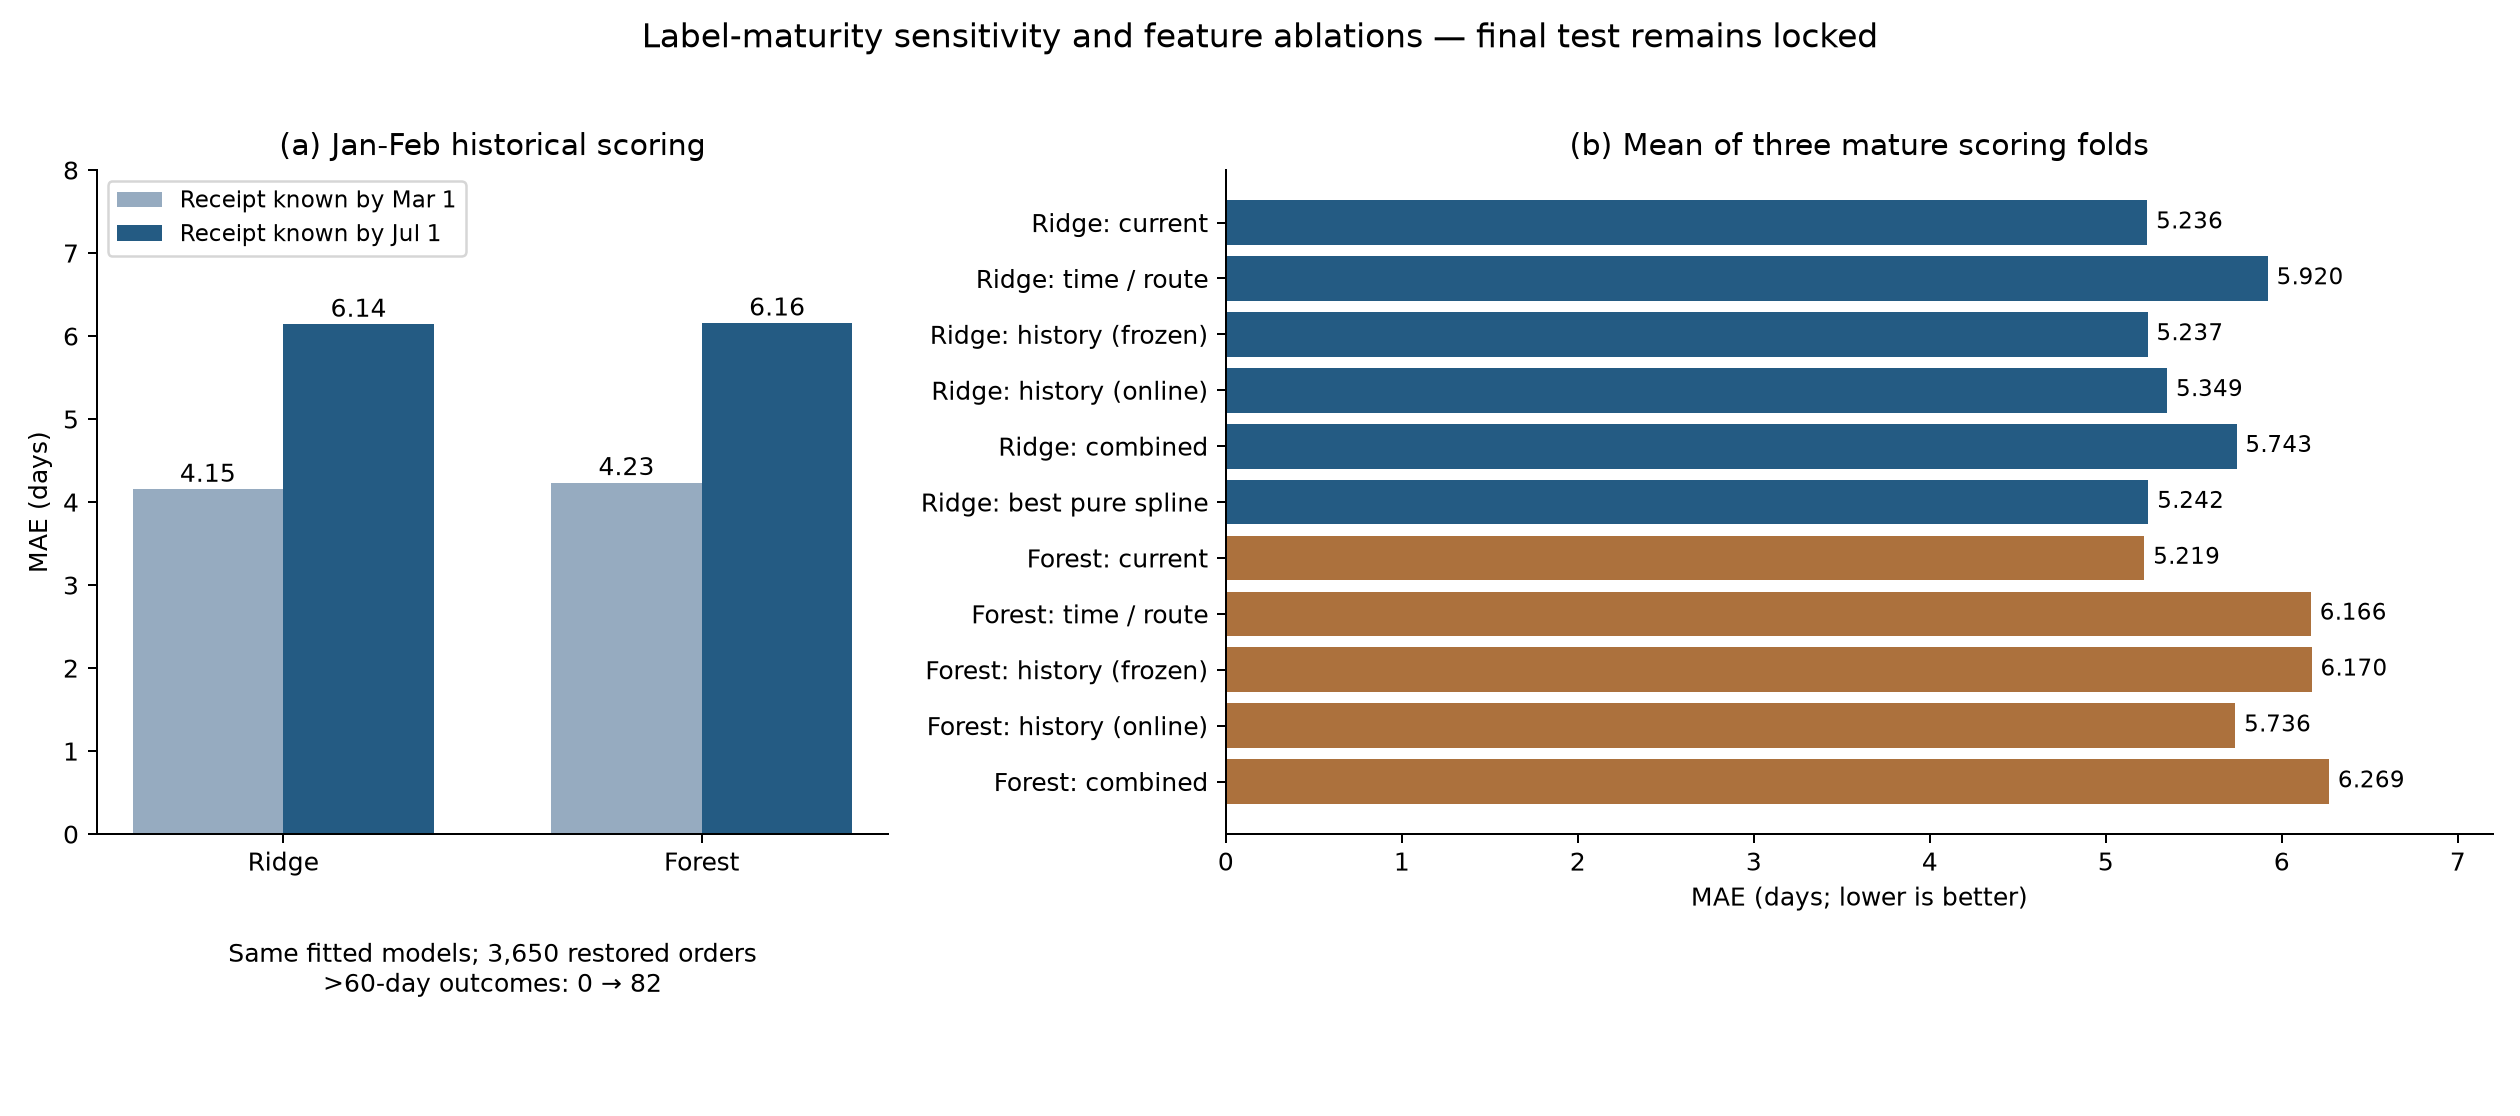

In [3]:
if RUN_EXPERIMENT:
    comparison, predictions = feature.evaluate(eligible, orders, specs, chosen)
else:
    comparison = pd.read_csv(feature.DEST/"outputs/tables/model_comparison.csv")
display(comparison.round(3))
from plot_feature_optimization import plot
figure_path = plot()
display(Image(filename=str(figure_path)))

## Takeaways

The experiment supports retaining the simpler selected feature schema rather than adding complexity without demonstrated benefit. It corrects the optimistic historical evaluation and records unsuccessful variants. Mature-CV mean error of about 5.2 days still differs from March 6.8–6.9 days: this remaining gap is observed, with its operational cause unestablished.

MAE, bias and slow-delivery errors remain too large to claim accurate arrival-day promises. The development exercise can support an honest Phase 2 comparison, not a claim that the forecasting problem is solved. Freeze any final candidate design before the separate stacking/final-test steps. The canonical first-run handoff remains labelled historical v1; these isolated v2/v3 experiments must not be mixed with it.

AI assisted implementation and review; findings are tied to executed outputs and independent event-time checks.

## Independent Validation

Direct filtering checks 90-day means, smoothing and pending-receipt proxies against prefix/event-sweep computations. Tests mutate current/future outcomes and verify unchanged features at the relevant prediction instant. They also recompute metrics, reload models, check fit-only imputation and OOF membership, and verify original private handoff hashes.

In [4]:
from verify_feature_optimization import verify
validation_audit = verify()

{
  "passed": true,
  "configurations": 18,
  "folds": 3,
  "historical_cohort_views": 2,
  "March_orders": 7003,
  "history_rows_independently_checked": 240,
  "future_outcome_mutation_invariance": true,
  "fit_only_imputation_checked": true,
  "selected_train_oof_rows": 39445,
  "pipelines_reloaded": true,
  "legacy_handoff_unchanged": true,
  "test_scored": false,
  "limits": "observed completed deliveries and frozen-origin history; mature CV labels known before July; adaptive development search, not nested CV or final testing"
}
